# PlotStyle Quickstart

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rahulkaushal04/plotstyle/blob/main/examples/notebooks/01_quickstart.ipynb)

**PlotStyle** makes it easy to create Matplotlib figures that meet the formatting rules of scientific journals like Nature, Science, and IEEE.

Instead of manually adjusting font sizes, figure dimensions, and colors, you pick a journal and PlotStyle handles everything.

**What you will learn:**
- Apply a journal style with `plotstyle.use()`
- Create correctly sized figures with `style.figure()`
- Get colorblind-safe color palettes with `style.palette()`
- Check your figure against journal rules with `style.validate()`
- Save a submission-ready file with `style.savefig()`
- Customise any journal style with overlays

> Run cells from top to bottom. The setup cell at the top imports everything needed for the examples below.


In [1]:
# Install plotstyle if needed (e.g., on Google Colab).
try:
    import plotstyle
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotstyle"])
    import plotstyle

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import plotstyle

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared x-axis data used across all examples
x = np.linspace(0, 2 * np.pi, 200)

## 1. Discover Available Journals

PlotStyle includes built-in presets for many major scientific publishers. Run the cell below to see the full list.

In [3]:
available = plotstyle.registry.list_available()
print(f"Available journals ({len(available)}): {', '.join(available)}")

Available journals (10): acs, cell, elsevier, ieee, nature, plos, prl, science, springer, wiley


## 2. Apply a Journal Style

`plotstyle.use("nature")` configures Matplotlib to match Nature's figure guidelines: fonts, text sizes, line weights, and more.

Using it as a `with` block is the recommended pattern. The original Matplotlib settings are restored automatically when the block ends, so one example does not affect the next.

The `as style` binding gives you a handle for creating figures and saving files, without needing to repeat the journal name.

/Users/rahulkaushal/plotstyle/src/plotstyle/core/style.py:772: SpecAssumptionWarning: "Nature" has no official values for line.min_weight_pt; plotstyle defaults will be used.
  spec = registry.get(journal_key)


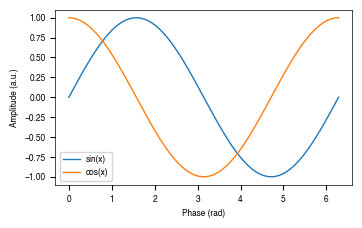

In [4]:
with plotstyle.use("nature") as style:
    # columns=1 creates a single-column figure (89 mm wide for Nature)
    fig, ax = style.figure(columns=1)

    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)")
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.legend()

    plt.show()
    plt.close(fig)

## 3. Multi-Panel Figures

`style.subplots()` creates a figure with multiple panels, correctly sized for the journal. It also automatically adds panel labels (a, b, c, ...) in the right font and style.

Access each panel using `axes[row, column]`. For example, `axes[0, 0]` is the first panel and `axes[0, 1]` is the second.

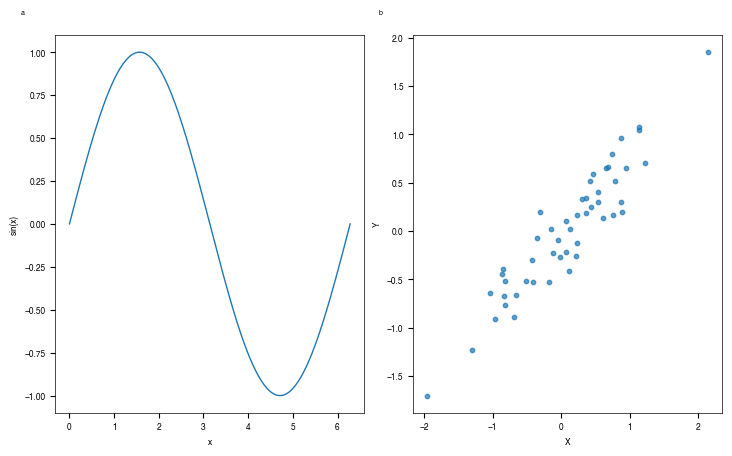

In [5]:
rng = np.random.default_rng(42)

with plotstyle.use("nature") as style:
    # columns=2 creates a double-column figure (full text width)
    fig, axes = style.subplots(nrows=1, ncols=2, columns=2)

    # Panel a: line plot
    axes[0, 0].plot(x, np.sin(x))
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("sin(x)")

    # Panel b: scatter plot
    xs = rng.normal(0, 1, 50)
    ys = 0.8 * xs + rng.normal(0, 0.3, 50)
    axes[0, 1].scatter(xs, ys, s=10, alpha=0.7)
    axes[0, 1].set_xlabel("X")
    axes[0, 1].set_ylabel("Y")

    plt.show()
    plt.close(fig)

## 4. Color Palettes

Each journal preset includes a colorblind-safe palette. Use `style.palette()` to get a list of colors you can pass directly to Matplotlib.

You can also call `plotstyle.palette("nature", n=4)` outside a `with` block to get colors without applying any style.

Colors: ['#E69F00', '#56B4E9', '#009E73', '#F0E442']


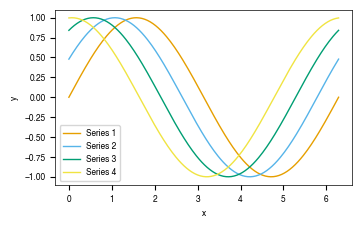

In [6]:
with plotstyle.use("nature") as style:
    colors = style.palette(n=4)
    print("Colors:", colors)

    fig, ax = style.figure(columns=1)
    for i, c in enumerate(colors):
        ax.plot(x, np.sin(x + i * 0.5), color=c, label=f"Series {i + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.show()
    plt.close(fig)

## 5. Validate Before Submission

`style.validate(fig)` checks your figure against the journal's rules: dimensions, font sizes, colors, and line weights. It prints a report showing what passed, what failed, and how to fix any issues.

In [7]:
with plotstyle.use("nature") as style:
    fig, ax = style.figure(columns=1)
    ax.plot(x, np.sin(x))
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    report = style.validate(fig)
    print(report)
    print(f"\nPassed: {report.passed}")
    plt.close(fig)

┌──────────────────────────────────────────────────────┐
│         PlotStyle Validation Report: Nature          │
├──────────┬───────────────────────────────────────────┤
│ ✓ PASS   │ Figure width 89.0mm matches single colu...│
│ ✓ PASS   │ Figure height 55.0mm is within the Natu...│
│ ✓ PASS   │ pdf.fonttype = 42 (TrueType fonts will ...│
│ ✓ PASS   │ ps.fonttype = 42 (TrueType fonts will b...│
│ ✓ PASS   │ savefig.dpi = 300.0 meets the Nature mi...│
│ ✓ PASS   │ All plotted lines and spines meet the N...│
│ ✓ PASS   │ All text elements are within the Nature...│
└──────────┴───────────────────────────────────────────┘
7/7 checks passed, 0 warning(s), 0 failure(s)

Passed: True


## 6. Save Your Figure

`style.savefig()` saves your figure in a submission-ready format. It automatically applies the journal's required resolution (DPI) and ensures fonts are embedded correctly, which is a common requirement of journal submission portals.

In [8]:
with plotstyle.use("nature") as style:
    fig, ax = style.figure(columns=1)
    ax.plot(x, np.sin(x))
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Amplitude")

    style.savefig(fig, OUTPUT_DIR / "quickstart_output.pdf")
    plt.close(fig)

print("Saved to output/quickstart_output.pdf")

Saved to output/quickstart_output.pdf


✓ TrueType fonts embedded (pdf.fonttype=42)
✓ Resolution: 300.0 DPI
✓ Dimensions: 3.50in x 2.17in
✓ Saved: output/quickstart_output.pdf


## 7. Overlays: Customise the Style

Overlays let you adjust one aspect of a journal preset without changing the base rules. Pass overlay names in a list alongside the journal key.

- `minimal`: strips the top and right spines for a clean, editorial look
- `okabe-ito`: swaps the color palette to a colorblind-safe 8-color set
- `notebook`: increases figure size and font size for Jupyter
- `bar`, `scatter`: optimises rcParams for specific chart types

See **[04_overlays.ipynb](04_overlays.ipynb)** for a full guide.

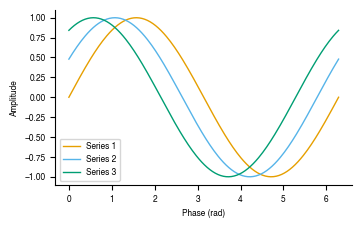

Context overlays: ['high-vis', 'minimal', 'notebook', 'presentation']
Color overlays:   ['okabe-ito', 'safe-grayscale', 'tol-bright', 'tol-high-contrast', 'tol-light', 'tol-muted', 'tol-rainbow-10', 'tol-rainbow-12', 'tol-rainbow-4', 'tol-rainbow-6', 'tol-rainbow-8', 'tol-vibrant']


In [9]:
# Nature style with the 'minimal' overlay: no top/right spines
with plotstyle.use(["nature", "minimal"]) as style:
    fig, ax = style.figure(columns=1)
    for i, color in enumerate(style.palette(n=3)):
        ax.plot(x, np.sin(x + i * 0.5), color=color, label=f"Series {i + 1}")
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    plt.show()
    plt.close(fig)

# List all available overlays
print("Context overlays:", plotstyle.list_overlays(category="context"))
print("Color overlays:  ", plotstyle.list_overlays(category="color"))